
Number of bits m :  4

User input theta binary after decimal point : 0.1011

Theta in decimal :  0.6875


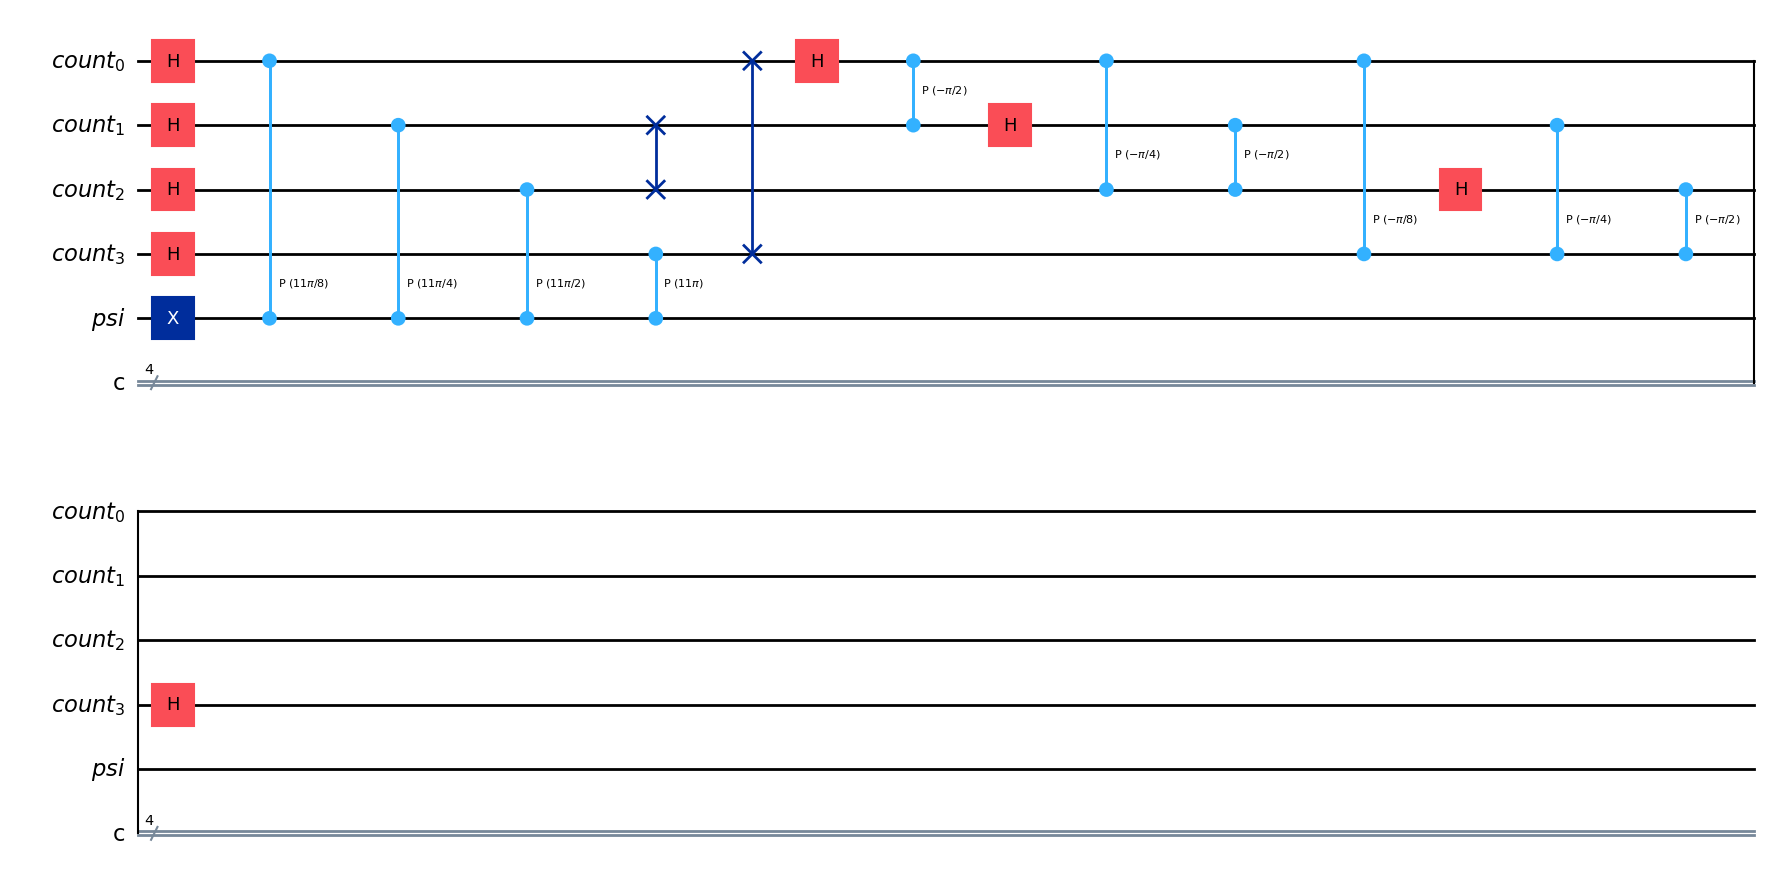


Measurement counts:
{'1011': 1024}


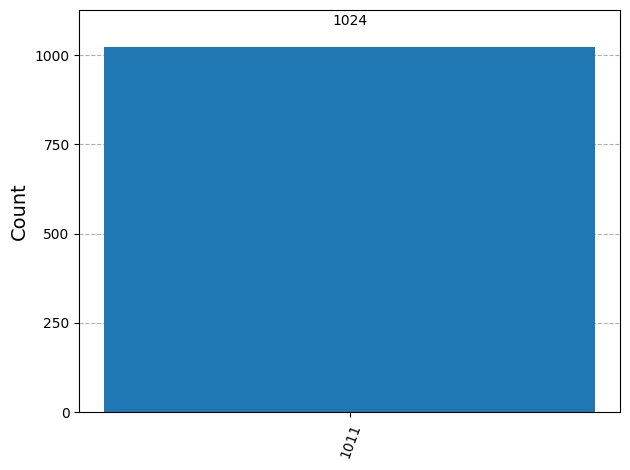


Measured binary from QPE: 1011
Expected theta binary     : 1011

Success: measured binary matches input theta binary.


In [ ]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import *
from qiskit . visualization import plot_histogram
from numpy import sqrt
from IPython.display import Math, display
from qiskit.circuit.library import UnitaryGate
from numpy import pi, cos, sin, exp
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector
import random
import numpy as np 

# Number of counting precision bits

bits_no = int(input("Enter the number of precision bits"))

# User enters theta bits after decimal point

theta_binary = str(input("Enter theta after binary decimal point in 0s and 1s: "))

print("\nNumber of bits m : ", bits_no)
print("\nUser input theta binary after decimal point : 0." + theta_binary)

# Safety checks

if len(theta_binary) != bits_no:
    raise ValueError("Theta binary length must be equal to m.")

if any(bit not in ["0", "1"] for bit in theta_binary):
    raise ValueError("Theta must contain only 0s and 1s.")

# Convert binary fraction 0.theta_binary to decimal theta

theta = 0

for i in range(bits_no):
    theta += int(theta_binary[i]) / (2**(i + 1))

print("\nTheta in decimal : ", theta)

# Total dimension of counting register

N = 2**bits_no


# Phase Estimation Circuit


# Top register: m counting qubits

count_reg = QuantumRegister(bits_no, "count")

# Bottom register: 1 eigenstate qubit psi

psi_reg = QuantumRegister(1, "psi")

# Classical register: m classical bits for measurement

classical_reg = ClassicalRegister(bits_no, "c")

# Quantum circuit with quantum + classical registers

circuit_1 = QuantumCircuit(count_reg, psi_reg, classical_reg)

# Initialize psi = |1>
# Because P(2πθ)|1> = e^(2πiθ)|1>

circuit_1.x(psi_reg[0])

# Apply Hadamard on top m counting qubits

for i in range(bits_no):
    circuit_1.h(count_reg[i])

# Controlled-U operations
# U = P(2πθ)
# U^(2^i) = P(2πθ * 2^i)

for i in range(bits_no):
    power = 2**i

    circuit_1.cp(
        2*pi*theta*power,
        count_reg[i],
        psi_reg[0]
    )

# Inverse QFT on counting register only

# First SWAP part

for i in range(bits_no // 2):
    circuit_1.swap(count_reg[i], count_reg[bits_no - i - 1])

# Inverse QFT main part

for i in range(bits_no):
    p = i

    for j in range(p):
        circuit_1.cp(
            -2*pi/(2**(p - j + 1)),
            count_reg[j],
            count_reg[p]
        )

    circuit_1.h(count_reg[p])

display(circuit_1.draw(output="mpl"))


# Measure first m qubits, i.e. counting register


for i in range(bits_no):
    circuit_1.measure(count_reg[i], classical_reg[i])

# Simulate and output measured binary


sim = AerSimulator()

result = sim.run(circuit_1, shots=1024).result()
counts = result.get_counts()

print("\nMeasurement counts:")
print(counts)

display(plot_histogram(counts))

# Most probable measured output

measured_binary = max(counts, key=counts.get)

print("\nMeasured binary from QPE:", measured_binary)
print("Expected theta binary     :", ''.join(theta_binary))

if measured_binary == ''.join(theta_binary):
    print("\nSuccess: measured binary matches input theta binary.")
else:
    print("\nNot matched.")
